In [1]:
import matplotlib as lib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pylab
import pandas as pd
import os
import pickle
%matplotlib inline

In [2]:
generation_list = []

for i in range(20002):
    generation_list.append(i)
    
print(len(generation_list))

20002


### RM

In [3]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20180510_Check the equilibrium of faculative sex_GMU =0.1_Revised sex\Data\1. N500_Diff Sexual Freq\Fitness")

In [4]:
file_20 = ['Fitness_RM_E1_N500_180510_RvSex.csv','Fitness_RM_E2_N500_180510_RvSex.csv','Fitness_RM_E5_N500_180510_RvSex.csv','Fitness_RM_E10_N500_180510_RvSex.csv', \
          'Fitness_RM_E20_N500_180510_RvSex.csv', 'Fitness_RM_E50_N500_180510_RvSex.csv', 'Fitness_RM_E100_N500_180510_RvSex.csv', \
          'Fitness_RM_E200_N500_180510_RvSex.csv', 'Fitness_RM_E500_N500_180510_RvSex.csv']

In [5]:
f20_fit_mean = []
f20_fit_std = []

f20_var_mean = []
f20_var_std = []

for i in file_20:
    f = pd.read_csv(i,dtype=str)
    
    fit_mean = []
    fit_std = []
    
    var_mean = []
    var_std = []
       
    fit_mean.extend(list(pd.Series(f.meanFit,dtype=float)))
    fit_std.extend(list(pd.Series(f.PopMeanFit_STD,dtype=float)))
    
    var_mean.extend(list(pd.Series(f.PopVar_Mean,dtype=float)))
    var_std.extend(list(pd.Series(f.PopVar_STD,dtype=float)))
    
    f20_fit_mean.append(fit_mean)
    f20_fit_std.append(fit_std)
    
    f20_var_mean.append(var_mean)
    f20_var_std.append(var_std)

In [6]:
def publication_figure2(axis):
    plt.rcParams.update({'font.size': 18})
    ax = axis
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(4)
    ax.spines['bottom'].set_linewidth(4)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    #ax.xaxis.set_ticks([])
    ax.tick_params(axis='x', which='both', bottom='on', top='off',labelbottom='on', size=10, width=5, direction='out', pad=25, colors='black')
    ax.tick_params(axis='y', which='both', left='on', right='off',labelbottom='on', size=10, width=5, direction='out', pad=25, colors='black')

In [7]:
def get_fit(gen_file, fit_file, std_file):
    with open(gen_file, 'rb') as f:
        sex_gen = pickle.load(f)
        
    sex_fit_mean = []
    sex_fit_std = []
    for i in sex_gen:
        sex_fit_mean.append(fit_file[i])
        sex_fit_std.append(std_file[i])
        
    return sex_fit_mean, sex_fit_std, sex_gen

In [8]:
e1 = get_fit('RM_E1_SEX_GEN_RvSex', f20_fit_mean[0], f20_fit_std[0])
sex_e1_fit_mean = e1[0]
sex_e1_fit_std = e1[1]
sex_e1_gen = e1[2]

In [9]:
e2 = get_fit('RM_E2_SEX_GEN_RvSex', f20_fit_mean[1], f20_fit_std[1])
sex_e2_fit_mean = e2[0]
sex_e2_fit_std = e2[1]
sex_e2_gen = e2[2]

In [10]:
e5 = get_fit('RM_E5_SEX_GEN_RvSex', f20_fit_mean[2], f20_fit_std[2])
sex_e5_fit_mean = e5[0]
sex_e5_fit_std = e5[1]
sex_e5_gen = e5[2]

In [11]:
e10 = get_fit('RM_E10_SEX_GEN_RvSex', f20_fit_mean[3], f20_fit_std[3])
sex_e10_fit_mean = e10[0]
sex_e10_fit_std = e10[1]
sex_e10_gen = e10[2]

In [12]:
e20 = get_fit('RM_E20_SEX_GEN_RvSex', f20_fit_mean[4], f20_fit_std[4])
sex_e20_fit_mean = e20[0]
sex_e20_fit_std = e20[1]
sex_e20_gen = e20[2]

In [13]:
e50 = get_fit('RM_E50_SEX_GEN_RvSex', f20_fit_mean[5], f20_fit_std[5])
sex_e50_fit_mean = e50[0]
sex_e50_fit_std = e50[1]
sex_e50_gen = e50[2]

In [14]:
e100 = get_fit('RM_E100_SEX_GEN_RvSex', f20_fit_mean[6], f20_fit_std[6])
sex_e100_fit_mean = e100[0]
sex_e100_fit_std = e100[1]
sex_e100_gen = e100[2]

In [15]:
e200 = get_fit('RM_E200_SEX_GEN_RvSex', f20_fit_mean[7], f20_fit_std[7])
sex_e200_fit_mean = e200[0]
sex_e200_fit_std = e200[1]
sex_e200_gen = e200[2]

In [16]:
e500 = get_fit('RM_E500_SEX_GEN_RvSex', f20_fit_mean[8], f20_fit_std[8])
sex_e500_fit_mean = e500[0]
sex_e500_fit_std = e500[1]
sex_e500_gen = e500[2]

In [17]:
def expectation(ud, freq):
    return np.exp(-ud*2*freq/45)

In [18]:
expect_value = []

freq_list = [1, 2, 5, 10, 20, 50, 100, 200, 500]

for i in freq_list:
    expect_value.append(expectation(0.1, i))

In [19]:
expect_value

[0.9955654174830928,
 0.9911505004882849,
 0.97802287248460051,
 0.95652873910302927,
 0.91494722873003098,
 0.80073740291680806,
 0.64118038842995462,
 0.41111229050718745,
 0.10836802322189586]

In [20]:
rm_value = [sex_e1_fit_mean[-1], sex_e2_fit_mean[-1],sex_e5_fit_mean[-1], sex_e10_fit_mean[-1], sex_e20_fit_mean[-1], \
           sex_e50_fit_mean[-1], sex_e100_fit_mean[-1], sex_e200_fit_mean[-1], sex_e500_fit_mean[-1]]

In [21]:
rm_value

[0.99566981143703681,
 0.99554353343209889,
 0.99483125485453361,
 0.99458964139873784,
 0.99337668798438816,
 0.98708189903678867,
 0.97508099997880371,
 0.95343553760413813,
 0.8679949531375214]

In [22]:
rm_std = [sex_e1_fit_std[-1], sex_e2_fit_std[-1],sex_e5_fit_std[-1], sex_e10_fit_std[-1], sex_e20_fit_std[-1], \
           sex_e50_fit_std[-1], sex_e100_fit_std[-1], sex_e200_fit_std[-1], sex_e500_fit_std[-1]]

In [23]:
rm_std

[0.0020463639802308416,
 0.0021960660473767228,
 0.0023716294000709535,
 0.0025533600163495057,
 0.0030998573885526004,
 0.005214001846108483,
 0.012438166499449847,
 0.021831687620812234,
 0.048986309567186165]

In [27]:
def publication_figure_2(axis):
    plt.rcParams.update({'font.size': 22})
    ax = axis
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(4)
    ax.spines['bottom'].set_linewidth(4)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    #ax.xaxis.set_ticks([])
    ax.tick_params(axis='x', which='both', bottom='on', top='off',labelbottom='on', size=10, width=5, direction='out', pad=25, colors='black')
    ax.tick_params(axis='y', which='both', left='on', right='off',labelbottom='on', size=10, width=5, direction='out', pad=25, colors='black')

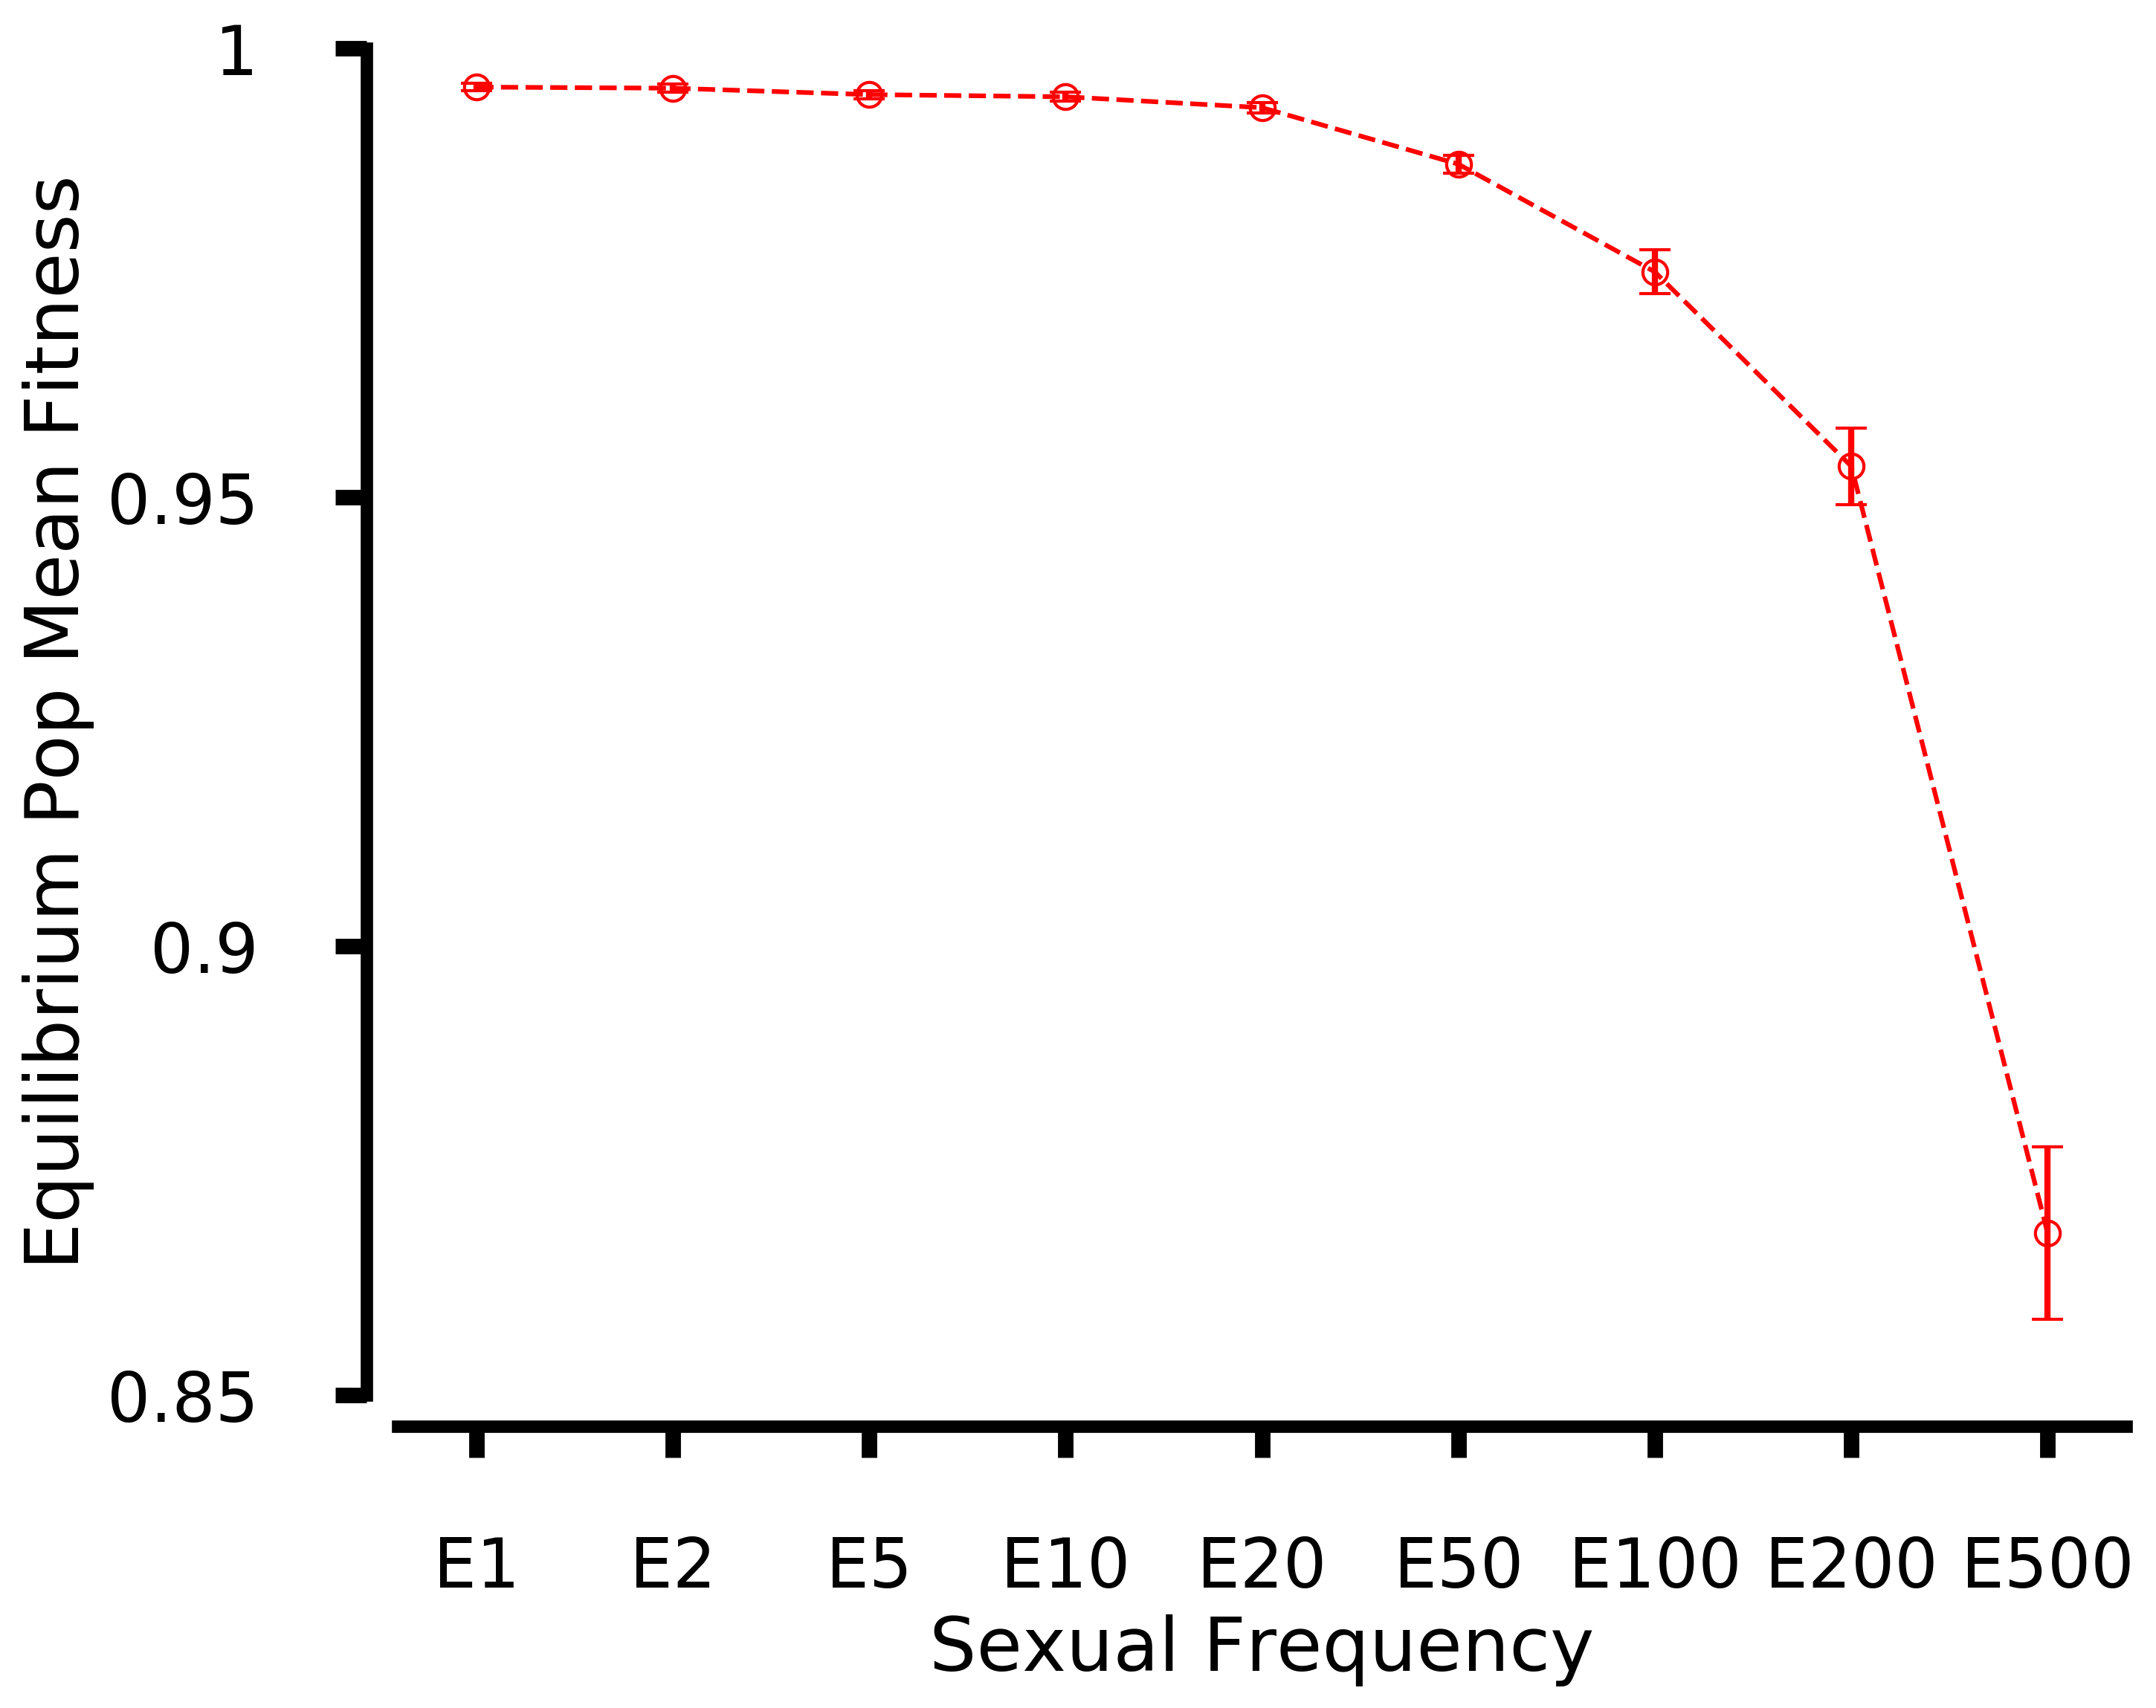

In [33]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

fig = plt.figure(figsize=(10,8), dpi =300)
ax = fig.add_subplot(111)
publication_figure_2(ax)

ax.set_ylim(0.85, 1.0)

x = range(1, 10)


# N =100
y2 = np.array(rm_value)
yerr2 = 1.96*np.array(rm_std)/((100)**0.5)
ax.errorbar(x, y2, yerr = yerr2, label ='Simulated Value', fmt='o', color = 'red', mfc='none', markersize =8, lw=2, capsize=5, capthick=1)
ax.plot(x,y2, color = 'red', ls = '--')


# N =1000
# y3 = np.array(expect_value)


# ax.plot(x,y3, marker='o', label = 'Expected Value', mfc='none', markersize =8, lw =2, color = 'dimgrey', ls = '--',)

# plt.legend(loc='lower left', frameon=False, prop={'size':20})

my_xticks = ['E1','E2', 'E5','E10','E20', 'E50', 'E100', 'E200', 'E500']
plt.xticks(x, my_xticks, rotation =0)


ax.set_yticks([0.85, 0.9, 0.95, 1]) # choose which x locations to have ticks
ax.set_yticklabels([ 0.85, 0.9, 0.95, 1]) # set the labels to display at those ticks


ax.set_xlabel('Sexual Frequency', fontsize =24)
ax.set_ylabel('Equilibrium Pop Mean Fitness', fontsize =24)

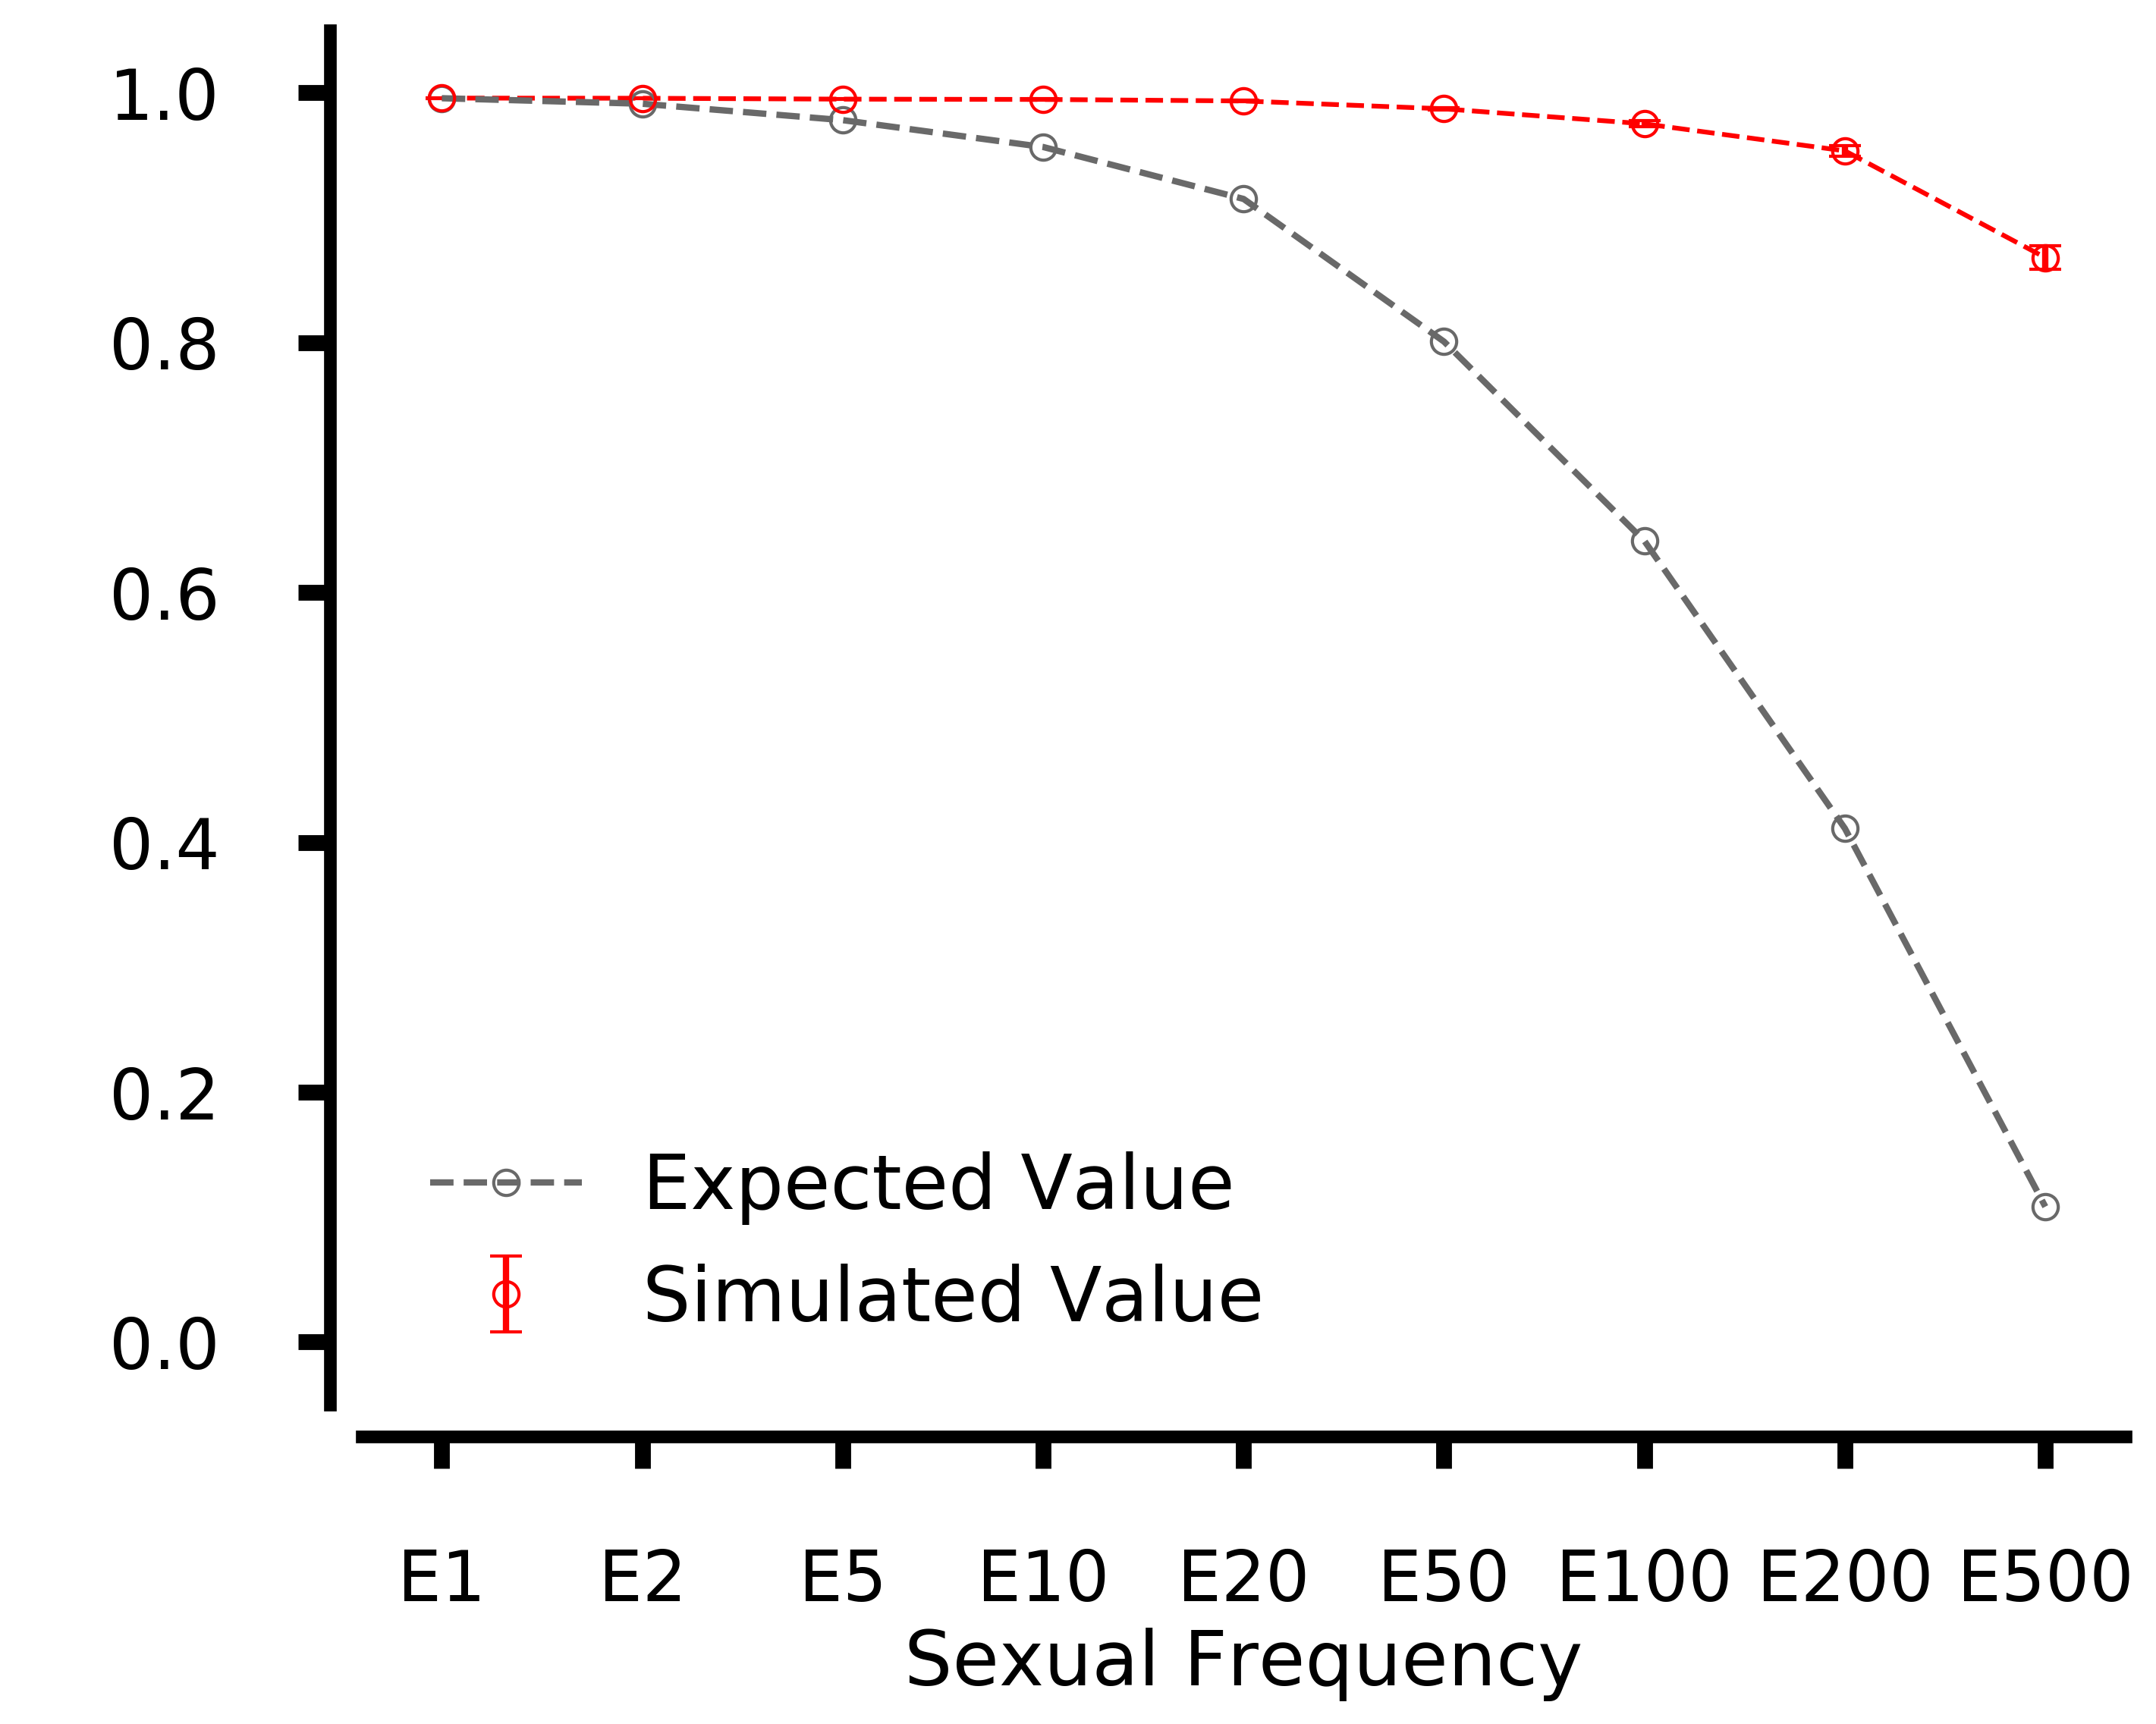

In [36]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

fig = plt.figure(figsize=(10,8), dpi =300)
ax = fig.add_subplot(111)
publication_figure_2(ax)

ax.set_ylim(-0.05, 1.05)

x = range(1, 10)


# N =100
y2 = np.array(rm_value)
yerr2 = 1.96*np.array(rm_std)/((100)**0.5)
ax.errorbar(x, y2, yerr = yerr2, label ='Simulated Value', fmt='o', color = 'red', mfc='none', markersize =8, lw=2, capsize=5, capthick=1)
ax.plot(x,y2, color = 'red', ls = '--')


# N =1000
y3 = np.array(expect_value)


ax.plot(x,y3, marker='o', label = 'Expected Value', mfc='none', markersize =8, lw =2, color = 'dimgrey', ls = '--',)

plt.legend(loc='lower left', frameon=False, prop={'size':24})

my_xticks = ['E1','E2', 'E5','E10','E20', 'E50', 'E100', 'E200', 'E500']
plt.xticks(x, my_xticks, rotation =0)


# ax.set_yticks([0.85, 0.9, 0.95, 1]) # choose which x locations to have ticks
# ax.set_yticklabels([ 0.85, 0.9, 0.95, 1]) # set the labels to display at those ticks


ax.set_xlabel('Sexual Frequency', fontsize =24)
ax.set_ylabel('Equilibrium Pop Mean Fitness', fontsize =24, color = 'w')

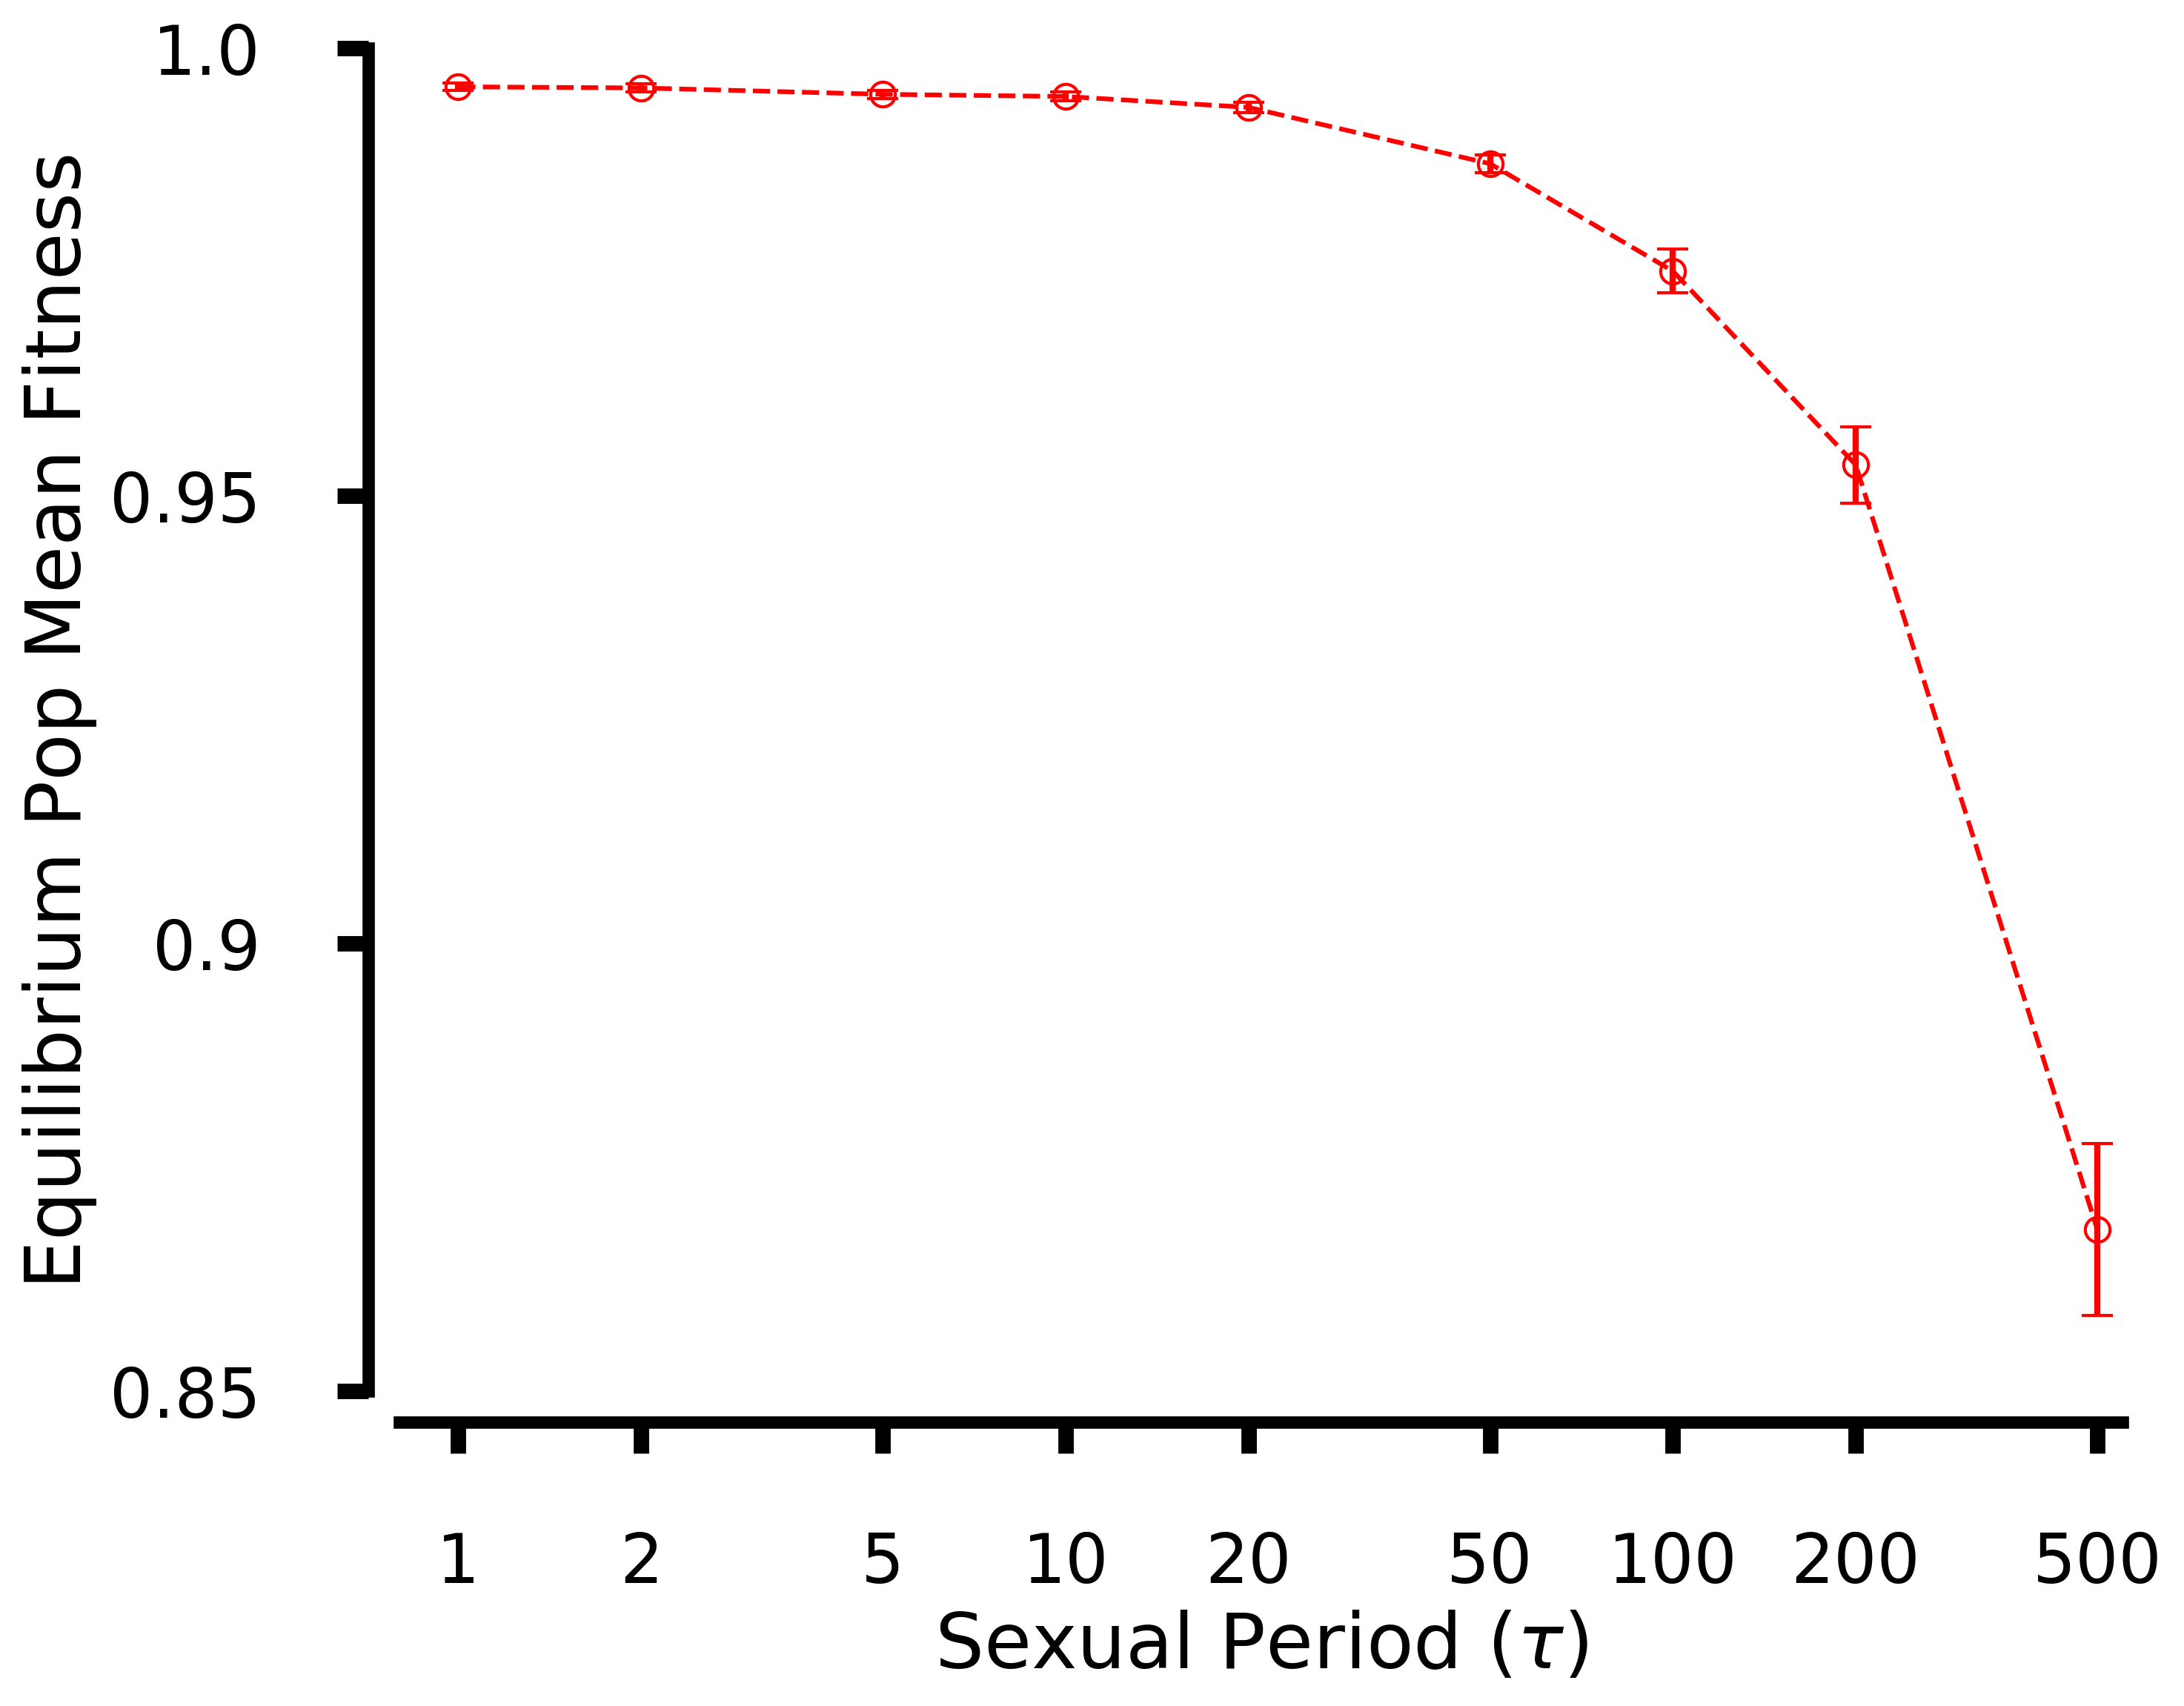

In [60]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

fig = plt.figure(figsize=(10,8), dpi =300)
ax = fig.add_subplot(111)
publication_figure_2(ax)

ax.set_ylim(0.85, 1.0)
ax.set_xlim(0.8,550)

x = [1, 2, 5, 10, 20, 50, 100, 200, 500]
ax.set_xscale('log',basex=2)

# N =100
y2 = np.array(rm_value)
yerr2 = 1.96*np.array(rm_std)/((100)**0.5)
ax.errorbar(x, y2, yerr = yerr2, label ='Simulated Value', fmt='o', color = 'red', mfc='none', markersize =8, lw=2, capsize=5, capthick=1)
ax.plot(x,y2, color = 'red', ls = '--')


# N =1000
# y3 = np.array(expect_value)


# ax.plot(x,y3, marker='o', label = 'Expected Value', mfc='none', markersize =8, lw =2, color = 'dimgrey', ls = '--',)

# plt.legend(loc='lower left', frameon=False, prop={'size':20})

ax.set_xticks([1, 2, 5, 10, 20, 50, 100, 200, 500]) # choose which x locations to have ticks
ax.set_xticklabels([1, 2, 5, 10, 20, 50, 100, 200, 500]) # set the labels to display at those ticks


ax.set_yticks([0.85, 0.9, 0.95, 1]) # choose which x locations to have ticks
ax.set_yticklabels([ 0.85, 0.9, 0.95, 1.0]) # set the labels to display at those ticks


ax.set_xlabel(r'Sexual Period $(\tau)$', fontsize =25)
ax.set_ylabel('Equilibrium Pop Mean Fitness', fontsize =25)

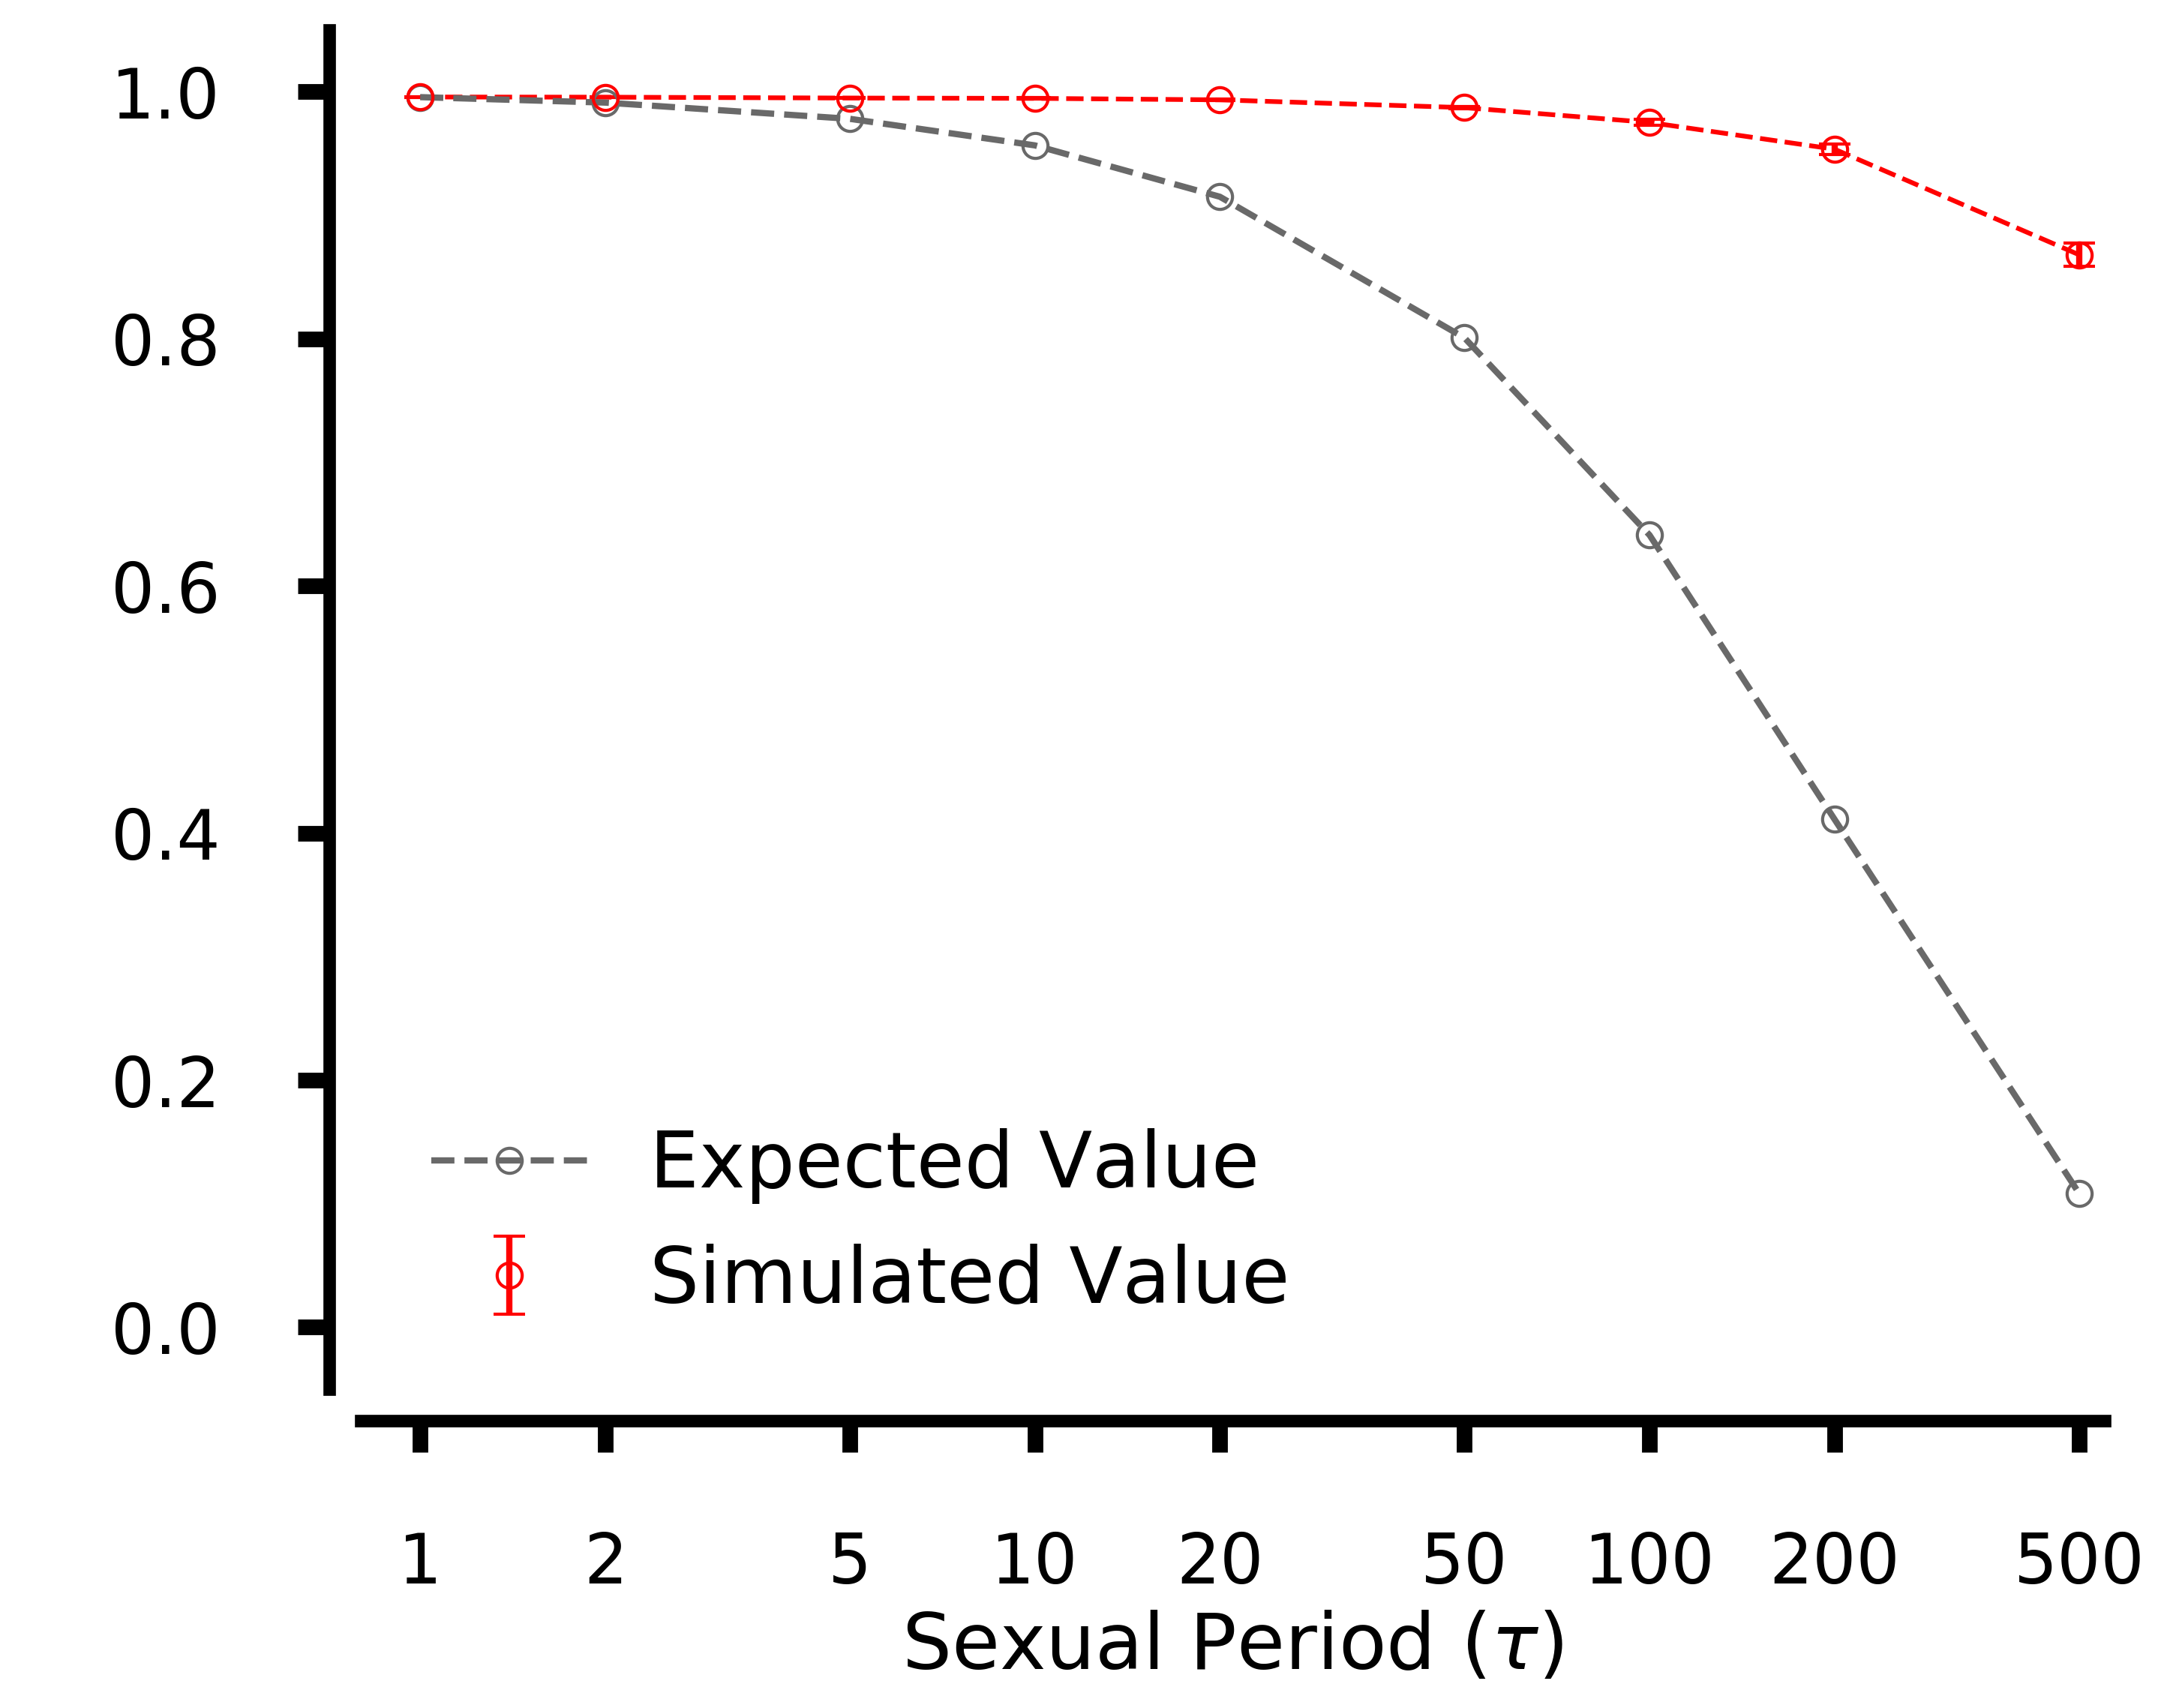

In [59]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

fig = plt.figure(figsize=(10,8), dpi =300)
ax = fig.add_subplot(111)
publication_figure_2(ax)

ax.set_ylim(-0.05, 1.05)
ax.set_xlim(0.8,550)

x = [1, 2, 5, 10, 20, 50, 100, 200, 500]
ax.set_xscale('log',basex=2)

# N =100
y2 = np.array(rm_value)
yerr2 = 1.96*np.array(rm_std)/((100)**0.5)
ax.errorbar(x, y2, yerr = yerr2, label ='Simulated Value', fmt='o', color = 'red', mfc='none', markersize =8, lw=2, capsize=5, capthick=1)
ax.plot(x,y2, color = 'red', ls = '--')


# N =1000
y3 = np.array(expect_value)


ax.plot(x,y3, marker='o', label = 'Expected Value', mfc='none', markersize =8, lw =2, color = 'dimgrey', ls = '--',)

plt.legend(loc='lower left', frameon=False, prop={'size':25})

ax.set_xticks([1, 2, 5, 10, 20, 50, 100, 200, 500]) # choose which x locations to have ticks
ax.set_xticklabels([1, 2, 5, 10, 20, 50, 100, 200, 500]) # set the labels to display at those ticks


# ax.set_yticks([0.85, 0.9, 0.95, 1]) # choose which x locations to have ticks
# ax.set_yticklabels([ 0.85, 0.9, 0.95, 1]) # set the labels to display at those ticks


ax.set_xlabel(r'Sexual Period $(\tau)$', fontsize =25)
ax.set_ylabel('Equilibrium Pop Mean Fitness', fontsize =25, color = 'w')